In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

In [3]:
custom_model = torch.load('best_deep_ln_07372_wd3e4.pt', map_location=device, weights_only=False)

for param in custom_model.layer3.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda x: x.requires_grad, custom_model.parameters()), lr=1e-5,
                                   weight_decay=3e-4)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-7)
deep_ft, metrics_ft = train_model(custom_model, criterion, optimizer, scheduler, dataloaders,
                                          dataset_sizes, 30)

val Loss: 0.7328 | Acc: 0.7467 | Weighted Acc: 0.7161 | F1-macro: 0.7482 | Top-1 Acc: 0.7467 | Top-3 Acc: 0.9414
Epoch Time: 20.4688s

Training complete in 10m 9s
Best val Weighted Acc: 0.721352 | Best F1-score: 0.7532 | Best Top-1 Acc: 0.7508 | Best Top-3 Acc: 0.9430


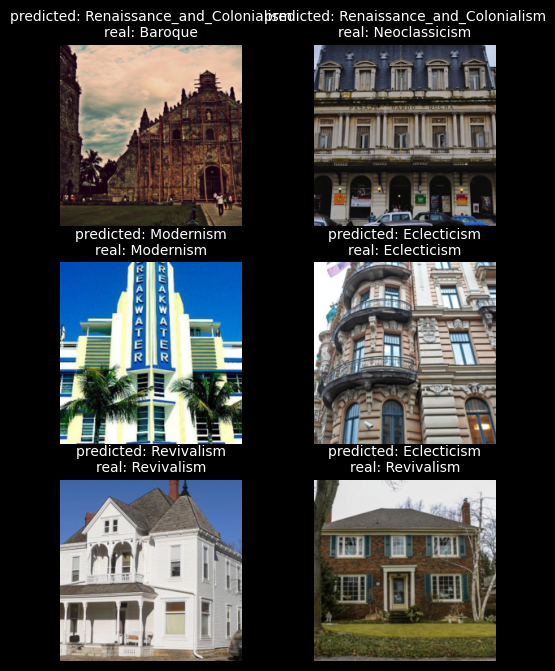

In [4]:
visualize_model(deep_ft, num_images=6, class_names=class_names, vis_loader=vis_loader)

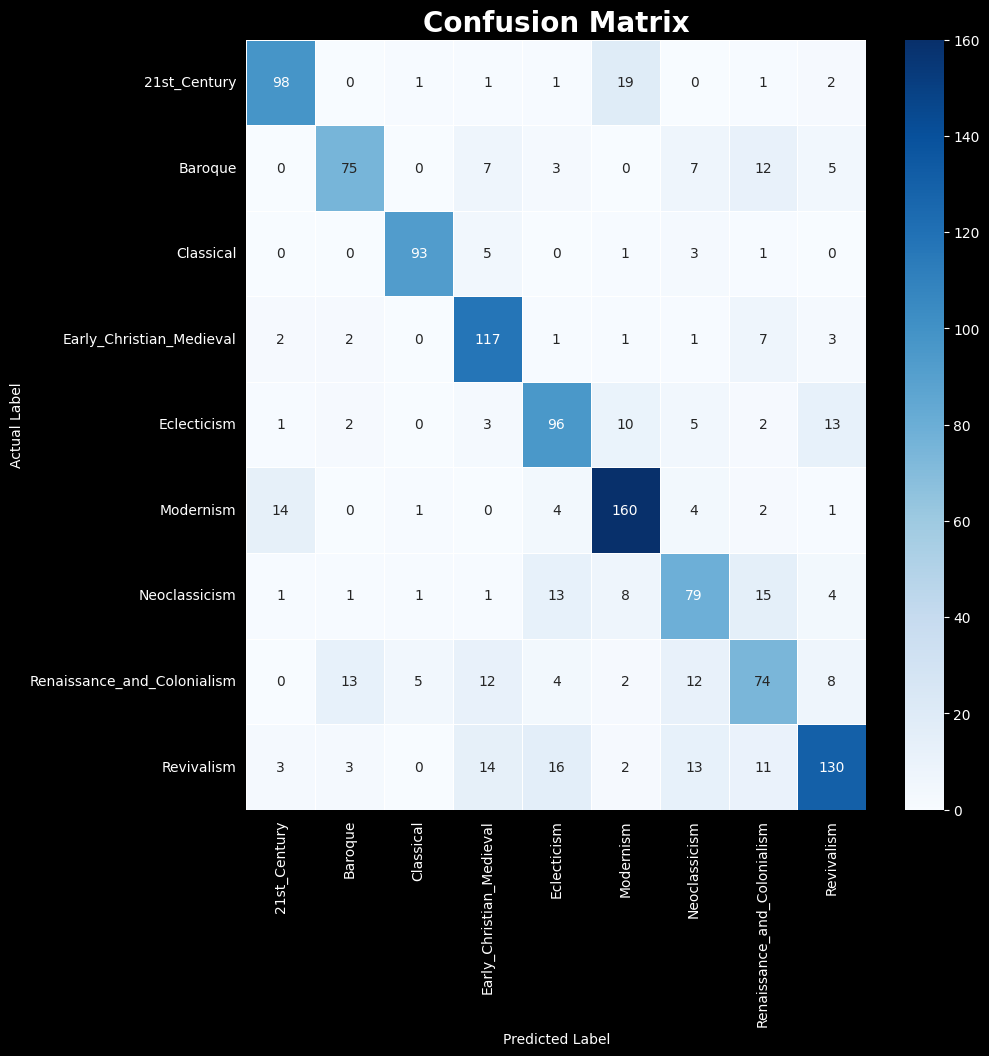

In [5]:
visualize_cm(deep_ft, class_names, test_set)

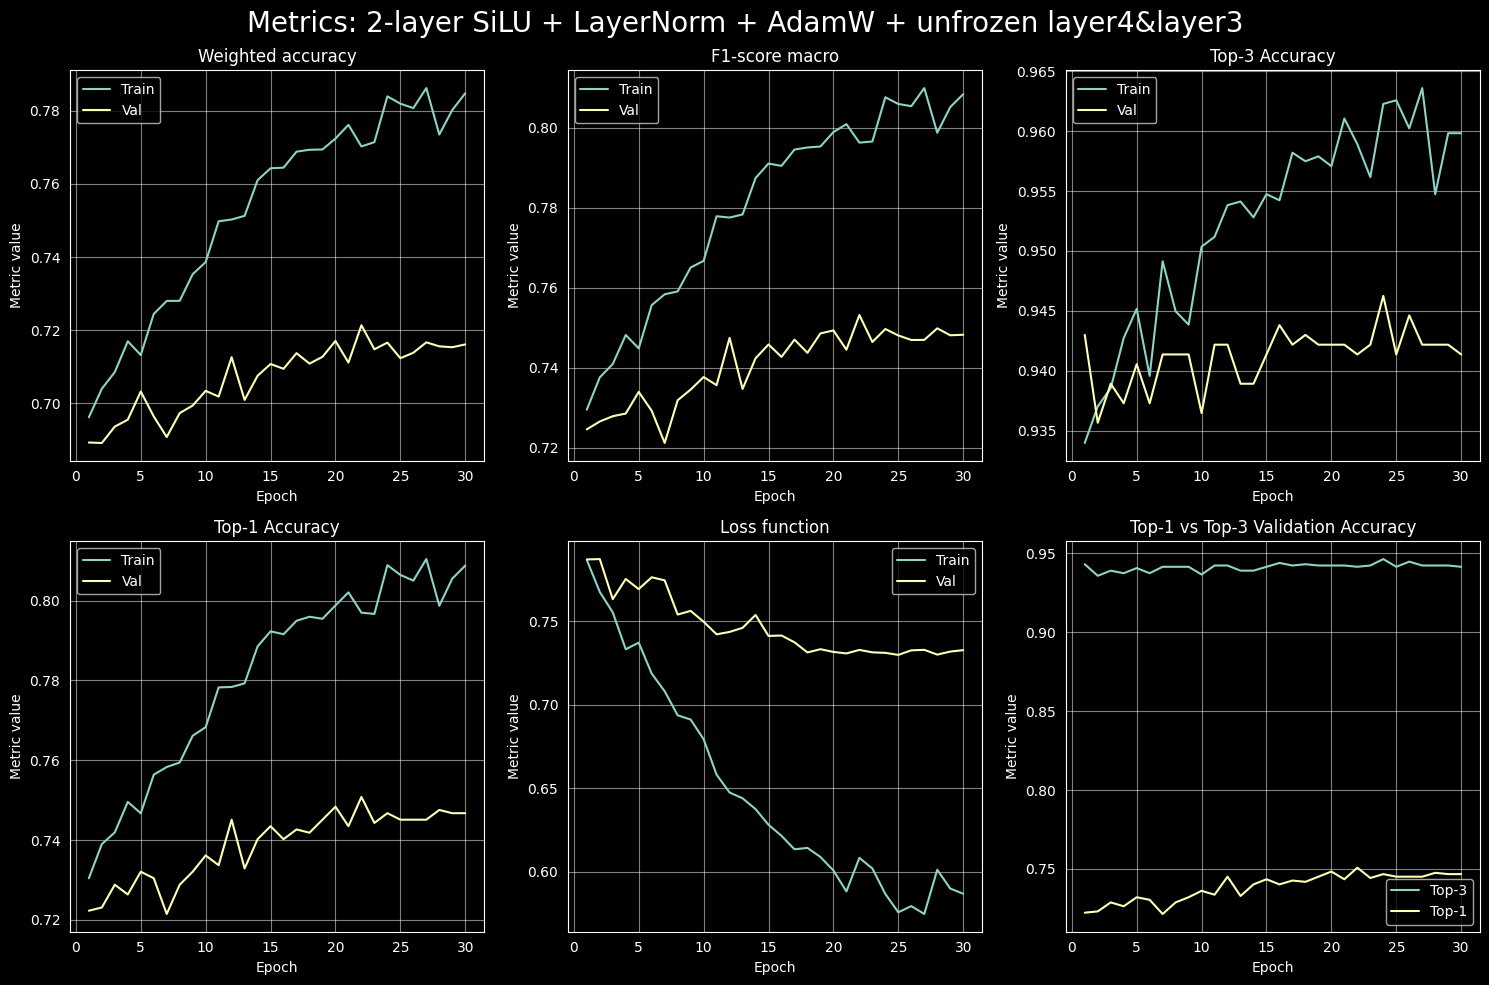

In [6]:
visualize_metrics(metrics_ft, "Metrics: 2-layer SiLU + LayerNorm + AdamW + unfrozen layer4&layer3", len(metrics_ft[0]))

In [7]:
torch.save(deep_ft, 'deep_ln_unfrozen_layer3_07532.pt')